### Import

In [1]:
import os
import gc
import time
import scipy
import pickle 
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt 

from sklearn import metrics
from sklearn.utils import resample
from sklearn.metrics import auc
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

### Path

In [2]:
path_results  = "./Results/"

### Read Results

In [3]:
lstm = pd.read_csv(path_results + '60mins_Results.csv')
lstm_ff = pd.read_csv(path_results + '5mins_Results.csv')
llm = pd.read_csv(path_results + 'Vital_Processed_3H_Results.csv')
lstm_llm = pd.read_csv(path_results + 'Processed_All_Results.csv')
lstm_llm_ff = pd.read_csv(path_results + 'TimeVariant.csv')

In [5]:
lstm = lstm[['patientid', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
lstm_ff = lstm_ff[['patientid', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
llm = llm[['patientid', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
lstm_llm = lstm_llm[['patientid', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
lstm_llm_ff = lstm_llm_ff[['patientid', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]

lstm.columns = ['patientid', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
lstm_ff.columns = ['patientid', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
llm.columns = ['patientid', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
lstm_llm.columns = ['patientid', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
lstm_llm_ff.columns = ['patientid', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']

In [6]:
lstm.head(2)

### ROC

In [8]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [9]:
def get_roc_ci(y_true, y_score):
    
    auc_scores = []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    for j in range(1000):
        try:
            yte_true_b, yte_pred_b = resample(y_true, y_score, replace=True, random_state=j)
            fpr, tpr, _ = metrics.roc_curve(yte_true_b, yte_pred_b)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0
            auc_scores.append(metrics.roc_auc_score(yte_true_b, yte_pred_b))
            
        except Exception as e:
            continue
    
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    
    tprs_upper = np.minimum(mean_tpr + 1.64 * std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - 1.64 * std_tpr, 0)
    
    auc = roc_auc_score(y_true, y_score)
    
    return mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc

In [10]:
def plot_roc_with_ci(mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))
    
    plt.plot(mean_fpr, mean_tpr, color='blue', lw=2, label='Mean ROC (AUC = %0.2f)' % np.mean(auc_ci))
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.3)
    
    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='red', label='Chance', alpha=0.8)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [11]:
mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci = get_roc_ci(lstm_llm_ff['icu_expire_flag'], lstm_llm_ff['PREDICT_PROB'])

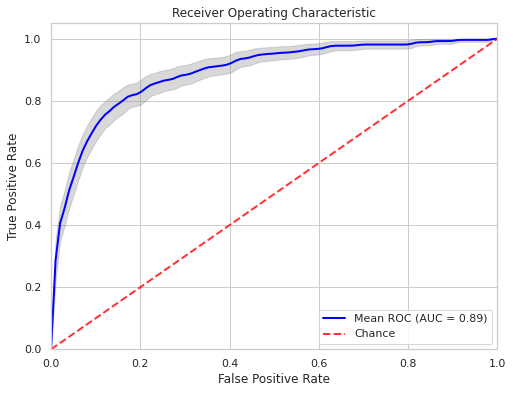

In [12]:
plot_roc_with_ci(mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci)

### Precision-Recall

In [13]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [14]:
def get_prc_ci(y_true, y_score):
    
    prc_scores = []
    precisions = []
    recalls = []
    thresholds = np.linspace(0, 1, 100)

    for j in range(1000):
        try:
            yte_true_b, yte_pred_b = resample(y_true, y_score, replace=True, random_state=j)
            precision, recall, _ = metrics.precision_recall_curve(yte_true_b, yte_pred_b)
            prc_score = metrics.auc(recall, precision)
            prc_scores.append(prc_score)
            interp_precision = np.interp(thresholds, recall[::-1], precision[::-1])
            precisions.append(interp_precision)
        except Exception as e:

            continue

    mean_precision = np.mean(precisions, axis=0)
    std_precision = np.std(precisions, axis=0)

    precision_upper = np.minimum(mean_precision + 1.15 * std_precision, 1)
    precision_lower = np.maximum(mean_precision - 1.15 * std_precision, 0)
    
    ap = average_precision_score(y_true, y_score)
    
    return thresholds, mean_precision, precision_lower, precision_upper, ap

In [15]:
def plot_prc_with_ci(thresholds, mean_precision, precision_lower, precision_upper, prc_ci):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))

    plt.plot(thresholds, mean_precision, color='blue', lw=2, label='Mean PRC (AP = %0.2f)' % np.mean(prc_ci))
    plt.fill_between(thresholds, precision_lower, precision_upper, color='grey', alpha=0.3,)
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

In [16]:
thresholds, mean_precision, precision_lower, precision_upper, prc_ci = get_prc_ci(lstm['icu_expire_flag'], lstm['PREDICT_PROB'])

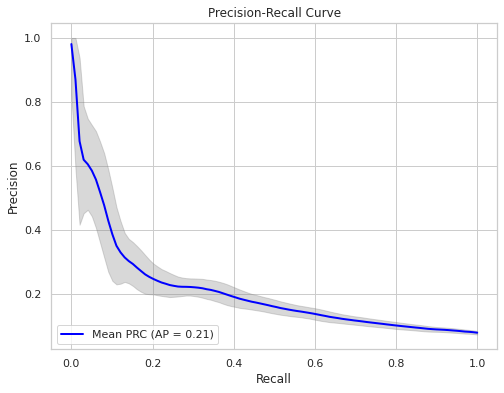

In [17]:
plot_prc_with_ci(thresholds, mean_precision, precision_lower, precision_upper, prc_ci)

### Performance Metrics

In [22]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    Brier = brier_score_loss(true_label, prediction_prob)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))
    print("Brier = " , np.round(Brier,  2))

In [23]:
def Performance_Metrics_CI(true_label, predicted_label, prediction_prob, n_bootstraps=1000, ci=95):
    
    metrics = {
        'ACC': [], 'PRC': [], 'REC': [], 'F1M': [], 'PPV': [],
        'NPV': [], 'SEN': [], 'SPE': [], 'FPR': [], 'FNR': [],
        'FDR': [], 'AUC': [], 'AP': [],  'MCC': [], 'BRR': []}
    
    for i in range(n_bootstraps):
        
        indices = resample(np.arange(len(true_label)), random_state=i)
        true_resampled = np.array(true_label)[indices]
        pred_resampled = np.array(predicted_label)[indices]
        prob_resampled = np.array(prediction_prob)[indices]
        
        TN, FP, FN, TP = confusion_matrix(true_resampled, pred_resampled).ravel()
        metrics['ACC'].append((TP + TN) / (TP + FP + FN + TN))
        metrics['PRC'].append(TP / (TP + FP) if TP + FP > 0 else 0)
        metrics['REC'].append(TP / (TP + FN) if TP + FN > 0 else 0)
        metrics['F1M'].append((2 * metrics['PRC'][-1] * metrics['REC'][-1]) / (metrics['PRC'][-1] + metrics['REC'][-1]) if metrics['PRC'][-1] + metrics['REC'][-1] > 0 else 0)
        metrics['PPV'].append(TP / (TP + FP) if TP + FP > 0 else 0)
        metrics['NPV'].append(TN / (TN + FN) if TN + FN > 0 else 0)
        metrics['SEN'].append(metrics['REC'][-1])
        metrics['SPE'].append(TN / (TN + FP) if TN + FP > 0 else 0)
        metrics['FPR'].append(FP / (FP + TN) if FP + TN > 0 else 0)
        metrics['FNR'].append(FN / (TP + FN) if TP + FN > 0 else 0)
        metrics['FDR'].append(FP / (TP + FP) if TP + FP > 0 else 0)
        metrics['AUC'].append(roc_auc_score(true_resampled, prob_resampled))
        metrics['AP'].append(average_precision_score(true_resampled, prob_resampled))
        metrics['MCC'].append(matthews_corrcoef(true_resampled, pred_resampled))
        metrics['BRR'].append(brier_score_loss(true_resampled, prob_resampled))

    ci_bounds = {}
    for key in metrics:
        lower = np.percentile(metrics[key], (100 - ci) / 2)
        upper = np.percentile(metrics[key], 100 - (100 - ci) / 2)
        mean  = np.mean(metrics[key])
        ci_bounds[key] = (mean, lower, upper)

    for metric, values in ci_bounds.items():
        print(f"{metric} = {values[0]:.3f} ({values[1]:.3f}-{values[2]:.3f})")

In [24]:
Performance_Metrics_CI(lstm['icu_expire_flag'], lstm['PREDICT_LABEL'], lstm['PREDICT_PROB'])

ACC = 0.429 (0.412-0.445)
PRC = 0.103 (0.090-0.117)
REC = 0.797 (0.747-0.846)
F1M = 0.182 (0.161-0.204)
PPV = 0.103 (0.090-0.117)
NPV = 0.958 (0.946-0.969)
SEN = 0.797 (0.747-0.846)
SPE = 0.397 (0.381-0.413)
FPR = 0.603 (0.587-0.619)
FNR = 0.203 (0.154-0.253)
FDR = 0.897 (0.883-0.910)
AUC = 0.680 (0.645-0.716)
AP = 0.212 (0.168-0.257)
MCC = 0.108 (0.078-0.137)
BRR = 0.445 (0.439-0.452)


In [25]:
Performance_Metrics_CI(lstm_ff['icu_expire_flag'], lstm_ff['PREDICT_LABEL'], lstm_ff['PREDICT_PROB'])

ACC = 0.450 (0.433-0.467)
PRC = 0.106 (0.093-0.121)
REC = 0.797 (0.744-0.844)
F1M = 0.188 (0.167-0.211)
PPV = 0.106 (0.093-0.121)
NPV = 0.960 (0.948-0.970)
SEN = 0.797 (0.744-0.844)
SPE = 0.420 (0.401-0.438)
FPR = 0.580 (0.562-0.599)
FNR = 0.203 (0.156-0.256)
FDR = 0.894 (0.879-0.907)
AUC = 0.703 (0.665-0.739)
AP = 0.249 (0.198-0.300)
MCC = 0.120 (0.088-0.148)
BRR = 0.294 (0.287-0.300)


In [26]:
Performance_Metrics_CI(llm['icu_expire_flag'], llm['PREDICT_LABEL'], llm['PREDICT_PROB'])

ACC = 0.762 (0.748-0.776)
PRC = 0.223 (0.196-0.249)
REC = 0.796 (0.746-0.841)
F1M = 0.348 (0.312-0.382)
PPV = 0.223 (0.196-0.249)
NPV = 0.977 (0.971-0.983)
SEN = 0.796 (0.746-0.841)
SPE = 0.759 (0.744-0.774)
FPR = 0.241 (0.226-0.256)
FNR = 0.204 (0.159-0.254)
FDR = 0.777 (0.751-0.804)
AUC = 0.852 (0.832-0.872)
AP = 0.372 (0.313-0.432)
MCC = 0.333 (0.297-0.366)
BRR = 0.190 (0.180-0.201)


In [27]:
Performance_Metrics_CI(lstm_llm['icu_expire_flag'], lstm_llm['PREDICT_LABEL'], lstm_llm['PREDICT_PROB'])

ACC = 0.859 (0.847-0.870)
PRC = 0.337 (0.300-0.374)
REC = 0.796 (0.746-0.843)
F1M = 0.473 (0.432-0.512)
PPV = 0.337 (0.300-0.374)
NPV = 0.980 (0.975-0.985)
SEN = 0.796 (0.746-0.843)
SPE = 0.864 (0.852-0.875)
FPR = 0.136 (0.125-0.148)
FNR = 0.204 (0.157-0.254)
FDR = 0.663 (0.626-0.700)
AUC = 0.905 (0.887-0.922)
AP = 0.555 (0.495-0.611)
MCC = 0.457 (0.418-0.499)
BRR = 0.167 (0.159-0.176)


In [28]:
Performance_Metrics_CI(lstm_llm_ff['icu_expire_flag'], lstm_llm_ff['PREDICT_LABEL'], lstm_llm_ff['PREDICT_PROB'])

ACC = 0.837 (0.825-0.850)
PRC = 0.303 (0.270-0.337)
REC = 0.796 (0.749-0.843)
F1M = 0.438 (0.401-0.477)
PPV = 0.303 (0.270-0.337)
NPV = 0.979 (0.974-0.985)
SEN = 0.796 (0.749-0.843)
SPE = 0.841 (0.828-0.854)
FPR = 0.159 (0.146-0.172)
FNR = 0.204 (0.157-0.251)
FDR = 0.697 (0.663-0.730)
AUC = 0.891 (0.870-0.911)
AP = 0.521 (0.452-0.584)
MCC = 0.424 (0.387-0.462)
BRR = 0.195 (0.184-0.205)


### Plotting Probability Distributions

In [29]:
def plot_kde(data, labels):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6), dpi=80)
    sns.kdeplot(data[labels == 0], label='Survived', shade=True)
    sns.kdeplot(data[labels == 1], label='Deceased', shade=True)
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Predicted Probability', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.legend()
    plt.show()

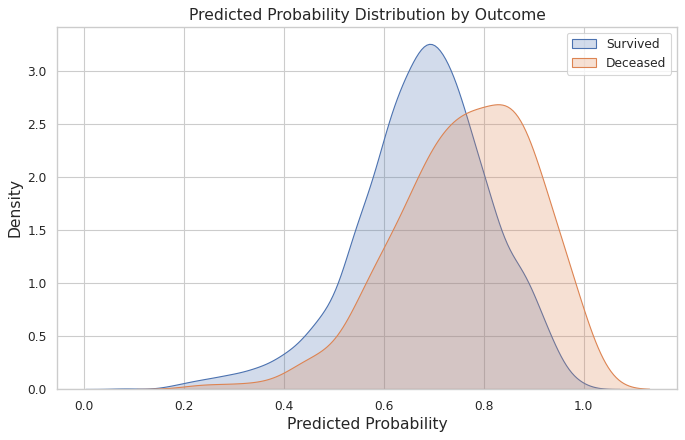

In [30]:
plot_kde(lstm['PREDICT_PROB'], lstm['icu_expire_flag'])

In [31]:
def plot_violin(data, labels):
    
    sns.set(style="whitegrid", context="talk")
    plt.figure(figsize=(10, 6), dpi=80)
    ax = sns.violinplot(x=labels, y=data, palette="muted", split=True)
    ax.set_xticklabels(['Survived', 'Deceased'])
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Outcome', fontsize=14)
    plt.ylabel('Predicted Probability', fontsize=14)
    plt.show()

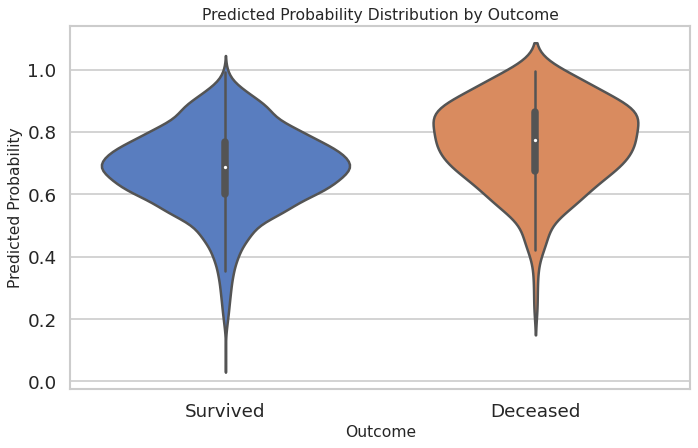

In [32]:
plot_violin(lstm['PREDICT_PROB'], lstm['icu_expire_flag'])

In [33]:
def plot_box(data, labels):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6), dpi=80)
    ax = sns.boxplot(x=labels, y=data, palette="muted")
    ax.set_xticklabels(['Survived', 'Deceased'], fontsize= 14)
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Outcome', fontsize=14)
    plt.ylabel('Predicted Probability', fontsize=14)
    plt.show()

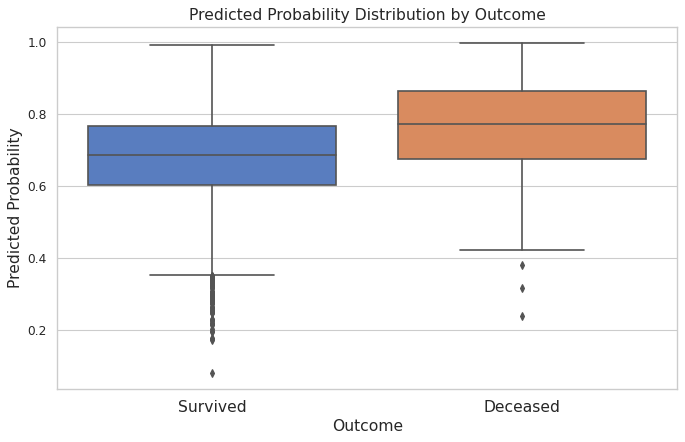

In [34]:
plot_box(lstm['PREDICT_PROB'], lstm['icu_expire_flag'])

### Plot ROC All

In [35]:
lstm_mean_fpr, lstm_mean_tpr, lstm_tprs_lower, lstm_tprs_upper, lstm_auc_ci = get_roc_ci(lstm['icu_expire_flag'], lstm['PREDICT_PROB'])
lstm_ff_mean_fpr, lstm_ff_mean_tpr, lstm_ff_tprs_lower, lstm_ff_tprs_upper, lstm_ff_auc_ci = get_roc_ci(lstm_ff['icu_expire_flag'], lstm_ff['PREDICT_PROB'])
llm_mean_fpr, llm_mean_tpr, llm_tprs_lower, llm_tprs_upper, llm_auc_ci = get_roc_ci(llm['icu_expire_flag'], llm['PREDICT_PROB'])
lstm_llm_mean_fpr, lstm_llm_mean_tpr, lstm_llm_tprs_lower, lstm_llm_tprs_upper, lstm_llm_auc_ci = get_roc_ci(lstm_llm['icu_expire_flag'], lstm_llm['PREDICT_PROB'])
lstm_llm_ff_mean_fpr, lstm_llm_ff_mean_tpr, lstm_llm_ff_tprs_lower, lstm_llm_ff_tprs_upper, lstm_llm_ff_auc_ci = get_roc_ci(lstm_llm_ff['icu_expire_flag'], lstm_llm_ff['PREDICT_PROB'])

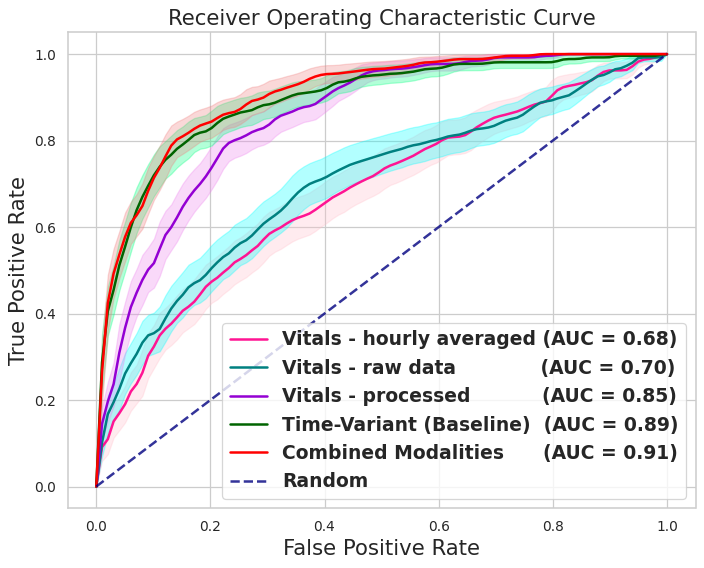

In [42]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(lstm_mean_fpr, lstm_mean_tpr, color='deeppink', lw=2, label='Vitals - hourly averaged (AUC = %0.2f)' % np.mean(lstm_auc_ci))
plt.fill_between(lstm_mean_fpr, lstm_tprs_lower, lstm_tprs_upper, color='pink', alpha=0.3)

plt.plot(lstm_ff_mean_fpr, lstm_ff_mean_tpr, color='teal', lw=2, label='Vitals - raw data             (AUC = %0.2f)' % np.mean(lstm_ff_auc_ci))
plt.fill_between(lstm_ff_mean_fpr, lstm_ff_tprs_lower, lstm_ff_tprs_upper, color='aqua', alpha=0.3)

plt.plot(llm_mean_fpr, llm_mean_tpr, color='darkviolet', lw=2, label='Vitals - processed           (AUC = %0.2f)' % np.mean(llm_auc_ci))
plt.fill_between(llm_mean_fpr, llm_tprs_lower, llm_tprs_upper, color='violet', alpha=0.3)

plt.plot(lstm_llm_ff_mean_fpr, lstm_llm_ff_mean_tpr, color='darkgreen', lw=2, label='Time-Variant (Baseline)  (AUC = %0.2f)' % np.mean(lstm_llm_ff_auc_ci))
plt.fill_between(lstm_llm_ff_mean_fpr, lstm_llm_ff_tprs_lower, lstm_llm_ff_tprs_upper, color='springgreen', alpha=0.3)

plt.plot(lstm_llm_mean_fpr, lstm_llm_mean_tpr, color='red', lw=2, label='Combined Modalities      (AUC = %0.2f)' % (np.mean(lstm_llm_auc_ci)))
plt.fill_between(lstm_llm_mean_fpr, lstm_llm_tprs_lower, lstm_llm_tprs_upper, color='lightcoral', alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='navy', label='Random', alpha=0.8)

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=17)
plt.ylabel('True Positive Rate', fontsize=17)
plt.title('Receiver Operating Characteristic Curve', fontsize=17)
# plt.legend(loc="lower right", fontsize=14)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold') 
plt.show()

### Plot Precision-Recall All

In [37]:
lstm_thresholds, lstm_mean_precision, lstm_precision_lower, lstm_precision_upper, lstm_prc_ci = get_prc_ci(lstm['icu_expire_flag'], lstm['PREDICT_PROB'])
lstm_ff_thresholds, lstm_ff_mean_precision, lstm_ff_precision_lower, lstm_ff_precision_upper, lstm_ff_prc_ci = get_prc_ci(lstm_ff['icu_expire_flag'], lstm_ff['PREDICT_PROB'])
llm_thresholds, llm_mean_precision, llm_precision_lower, llm_precision_upper, llm_prc_ci = get_prc_ci(llm['icu_expire_flag'], llm['PREDICT_PROB'])
lstm_llm_thresholds, lstm_llm_mean_precision, lstm_llm_precision_lower, lstm_llm_precision_upper, lstm_llm_prc_ci = get_prc_ci(lstm_llm['icu_expire_flag'], lstm_llm['PREDICT_PROB'])
lstm_llm_ff_thresholds, lstm_llm_ff_mean_precision, lstm_llm_ff_precision_lower, lstm_llm_ff_precision_upper, lstm_llm_ff_prc_ci = get_prc_ci(lstm_llm_ff['icu_expire_flag'], lstm_llm_ff['PREDICT_PROB'])

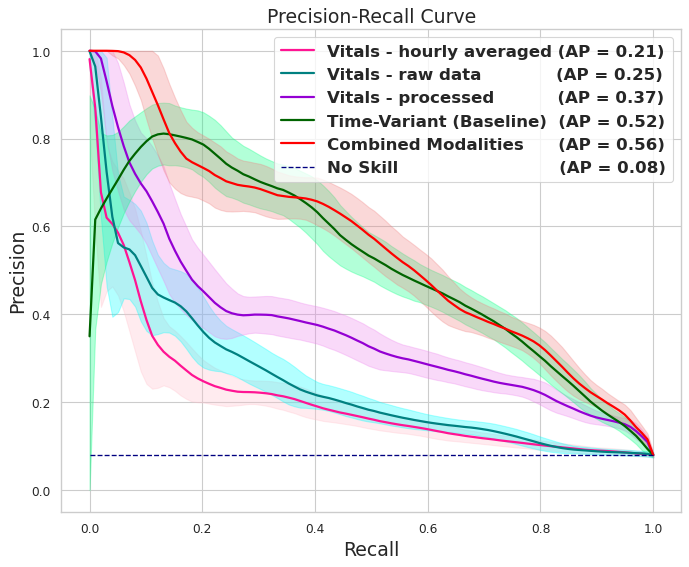

In [59]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 8), dpi=80)

plt.plot(lstm_thresholds, lstm_mean_precision, color='deeppink', lw=2, label='Vitals - hourly averaged (AP = %0.2f)' % np.mean(lstm_prc_ci))
plt.fill_between(lstm_thresholds, lstm_precision_lower, lstm_precision_upper, color='pink', alpha=0.3,)

plt.plot(lstm_ff_thresholds, lstm_ff_mean_precision, color='teal', lw=2, label='Vitals - raw data             (AP = %0.2f)' % np.mean(lstm_ff_prc_ci))
plt.fill_between(lstm_ff_thresholds, lstm_ff_precision_lower, lstm_ff_precision_upper, color='aqua', alpha=0.3,)

plt.plot(llm_thresholds, llm_mean_precision, color='darkviolet', lw=2, label='Vitals - processed           (AP = %0.2f)' % np.mean(llm_prc_ci))
plt.fill_between(llm_thresholds, llm_precision_lower, llm_precision_upper, color='violet', alpha=0.3,)

plt.plot(lstm_llm_ff_thresholds, lstm_llm_ff_mean_precision, color='darkgreen', lw=2, label='Time-Variant (Baseline)  (AP = %0.2f)' % np.mean(lstm_llm_ff_prc_ci))
plt.fill_between(lstm_llm_ff_thresholds, lstm_llm_ff_precision_lower, lstm_llm_ff_precision_upper, color='springgreen', alpha=0.3,)

plt.plot(lstm_llm_thresholds, lstm_llm_mean_precision, color='red', lw=2, label='Combined Modalities      (AP = %0.2f)' % (np.mean(lstm_llm_prc_ci)))
plt.fill_between(lstm_llm_thresholds, lstm_llm_precision_lower, lstm_llm_precision_upper, color='lightcoral', alpha=0.3,)

true_label = np.array(lstm['icu_expire_flag'])

no_skill = len(true_label[true_label == 1]) / len(true_label)
plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill                            (AP = {:.2f})'.format(no_skill))

plt.xlabel('Recall', fontsize=17)
plt.ylabel('Precision', fontsize=17)
plt.title('Precision-Recall Curve', fontsize=17)
# plt.legend(loc="best", fontsize=14)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()